# Week 5：紅綠燈、顯示器與真正的倒數時間

完整備課版（含參考解答）｜2026-10-07

一盞綠燈可以告訴玩家「現在允許遮光」，螢幕可以告訴玩家「剩下幾秒」。
但燈和螢幕都只是程式的輸出：要先決定現在的狀態，再把同一個決定呈現出來。
本週先做可停止、可重新準備的倒數器，暫不計算遮光得分，也不接舵機或外部電池。

### 教學目標

1. 依實物與核准資料辨認RGB的三個色彩接點、共同端及限流路徑。
2. 分辨OLED的供電、資料與時脈功能，說明位址掃描能證明及不能證明的事。
3. 用開始時間與目前時間算出剩餘毫秒，解釋顯示秒數的取整方式。
4. 對照程式狀態、序列紀錄、燈色與螢幕，找出不同步或過期的資訊。
5. 以控制變因的方法檢查RGB是否干擾光敏讀值，安全處理顯示失敗與手動復原。

### 教學內容

本週從可見的燈色與文字開始，建立「狀態、命令、實際輸出」三者的區別。
學生先分別驗證紅綠藍發光模組（RGB LED）與有機發光顯示器（OLED），
再用非阻塞式時間管理（non-blocking timing）協調倒數、換燈、畫面更新與命令處理。
最後利用顯示延遲與光線干擾情境，判斷畫面是否足以支持玩家的決定。

## 1. 開始前：先知道哪些東西可以接

本週使用ESP32-S3、USB資料線、RGB模組、核准的I2C OLED、麵包板、杜邦線及萬用電表。
最後的干擾比較才接回Week 3的KY-018。DHT11、蜂鳴器、按鈕、舵機與電池盒先收好，
避免沿用上一週接線而讓新程式控制到錯誤零件。

「核准設定（profile）」是這一片板卡與模組經文件核對及實機測試後的設定紀錄，
不是網路上找到的一組GPIO。現有RGB照片上的板號為HW-479；商品名KY-016不能代替板號。
OLED的控制器、解析度、位址、供電及訊號電壓仍須確認。沒有核准資料時可讀例子、
做紙上推理、編譯預設阻擋版本，不可猜接線後上電。

| 項目 | 必須確認的內容 | 不能用來代替的證據 |
|---|---|---|
| 開發板 | 確切PCB版型、可用GPIO、USB供電方式、3V3與GND | 單憑選到ESP32S3 Dev Module |
| RGB | 實物R/G/B共同端、共陰或共陽、限流電阻、各色電流及有效準位 | 看見四根腳、或模組上看見三顆電阻 |
| OLED | 廠商模組文件、控制器、解析度、介面、每腳標示、供電及SDA/SCL拉高電壓 | 「0.96吋」、I2C掃到0x3C、外觀相似 |
| 匯流排GPIO | SDA與SCL為兩個不同且可用的GPIO，與RGB及光敏不衝突 | 直接套用其他ESP32板的預設腳 |
| 程式版本 | 本週範例、ESP32 core及U8g2版本 | 曾經成功編譯另一支程式 |

核准數值與來源記在本書第11節紀錄表；查核入口為
[硬體狀態](../docs/hardware/hardware_state.md)。本書功能圖不表示已核准的實物左右腳序。
每次改線都先拔USB。只量低壓電路，不使用電流檔或10A插孔；Ω與通斷只在外部斷電後量。


## 2. RGB是三個色彩通道，不是三條電源

### 2.1 先看實物

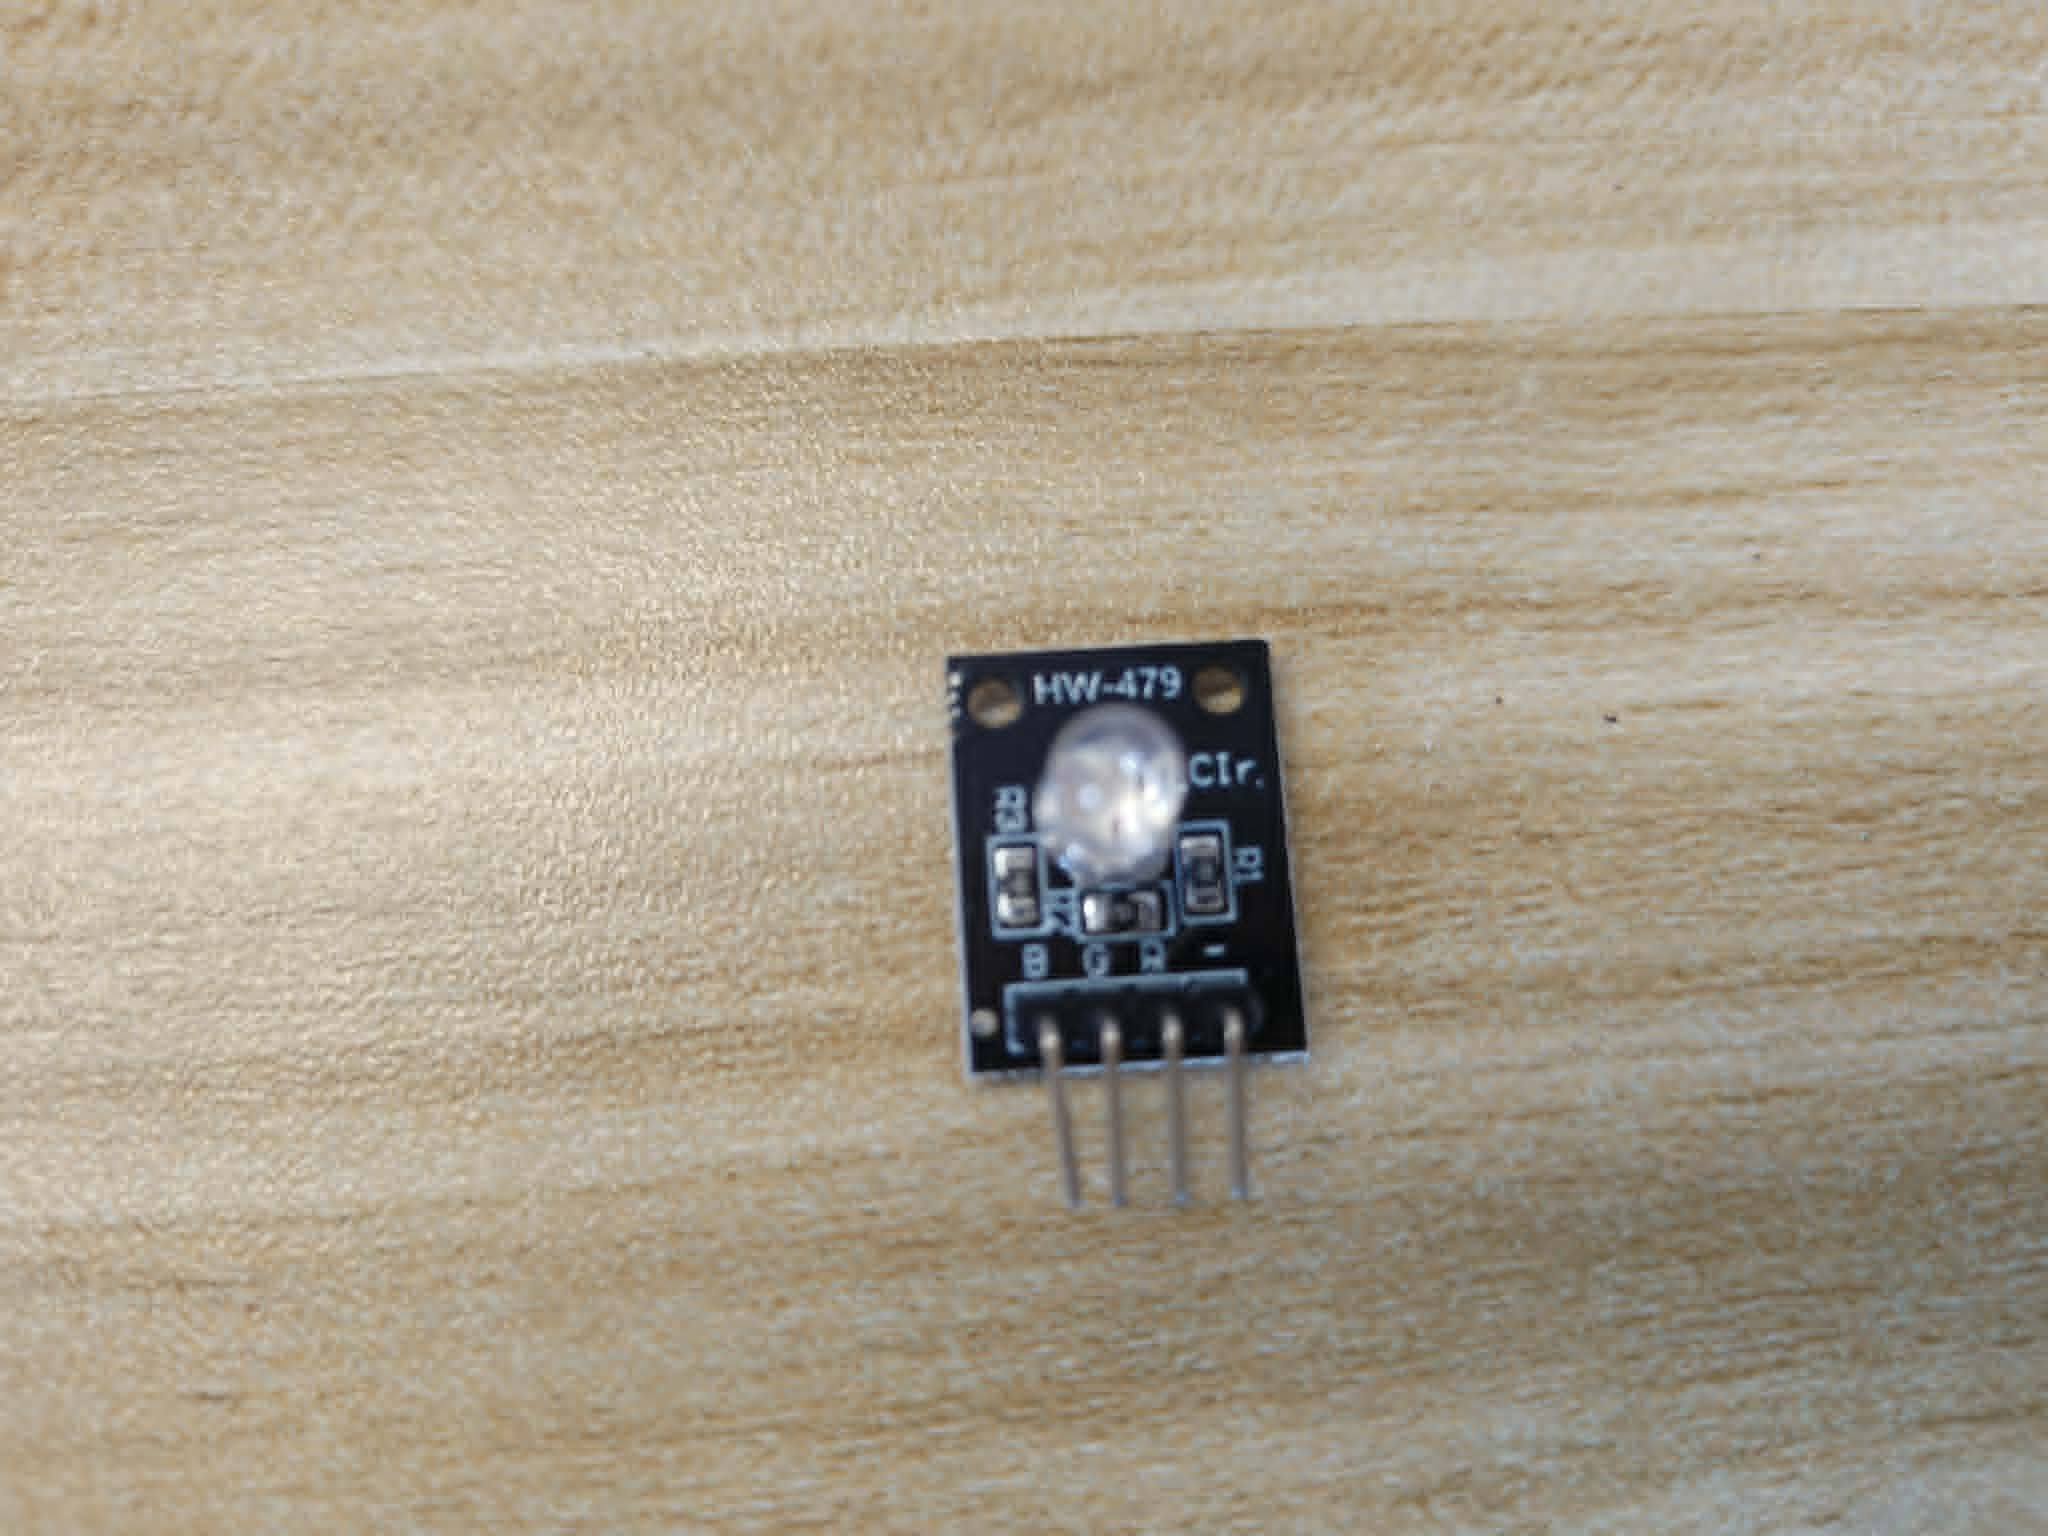

透明外殼中有紅（red）、綠（green）、藍（blue）三個發光通道。
R、G、B各自控制一種顏色，另一個共同接點和三個通道構成回路。
照片可幫助找到零件，但共陰／共陽與允許電流要看確切模組資料並核對實物。

共陰極（common cathode）把三個LED的陰極接在一起，通常共同端接GND，
控制端拉高時電流經限流電阻、LED回到GND。共陽極（common anode）則把陽極共接，
控制端拉低可能才亮。因此「HIGH就一定亮」不成立；本課用`RGB_ON_LEVEL`保存核准結果。
這是控制型態比較，不是准許把不明共同端試接3V3或GND。

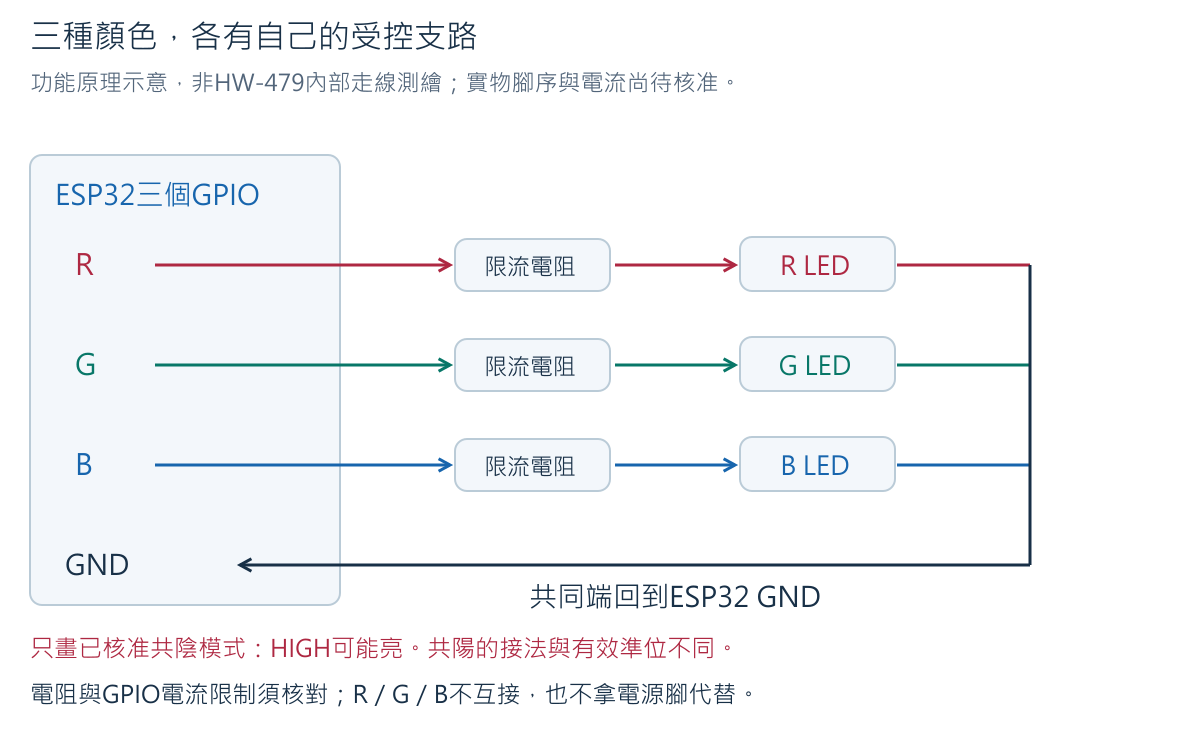

圖中的三條橫線是三個不同支路，不互相短接。只開紅通道時，綠、藍關閉。
限流電阻（current-limiting resistor）限制LED電流；它不是拿來「把多餘電流藏起來」。
以純計算例說，若供應3.3 V、某LED在這個工作點的壓降假設為2.0 V、串聯330 Ω，
則電阻兩端約1.3 V，電流約1.3 ÷ 330 = 0.00394 A = 3.94 mA。
2.0 V只是這個算例的假設，不是每色LED共同的規格；實際應核對各色資料、
模組已裝阻值、GPIO單腳與總電流限制。看到板上有電阻不代表任意電源都安全。

### 2.2 斷電接RGB：依功能，不背照片左右

1. 拔除USB，移除與本週無關的模組。ESP32不硬擠進麵包板，排針以母頭接出。
2. 依核准profile，把RGB共同端接指定的GND或3V3節點；兩者不能互換試錯。
3. R、G、B分別以母對母線連到三個核准GPIO。兩端都是排針所以使用母頭；
   若必須經麵包板延長，使用兩段公對母，每個色彩各占獨立五孔列。
4. 逐條從程式的PIN_RGB_R追到板上GPIO，再追到模組R；G、B及共同端同樣核對。
5. 上電前確認3V3與GND沒有持續低阻直通。通斷不響不等於完整安全認證；
   仍需核對供電、每一根線、限流及profile。

| 功能 | ESP32端 | 模組端 | 檢查重點 |
|---|---|---|---|
| 紅 | 核准PIN_RGB_R | 實物核准R | 不與G或B共用一列 |
| 綠 | 核准PIN_RGB_G | 實物核准G | 不是用綠色導線決定功能 |
| 藍 | 核准PIN_RGB_B | 實物核准B | 不與OLED或光敏重複GPIO |
| 共同端 | profile指定GND或3V3 | 核准共同端 | 共陰與共陽不能混用 |

**先預測**：若R與G兩條線接反，程式印`requested=r`會看到什麼？

**預期答案**：可能實物亮綠，因為log記的是程式要求紅，不是光學量測。
先停止、拔USB，再沿線查功能；不要只把畫面文字改成綠來掩蓋錯接。


## 3. OLED的四種功能：供電與通訊分開看

OLED的像素會發光。控制器（controller）負責把收到的指令變成畫面。
解析度（resolution）例如128×64，意思是橫128個、縱64個像素，不是電壓或公分。
I2C是一種裝置間的通訊方式：SDA承載資料，SCL提供配合資料傳送的時脈。
本週ESP32主動發起傳輸，OLED在自己的位址回應；VCC與GND則提供工作電力及共同參考。

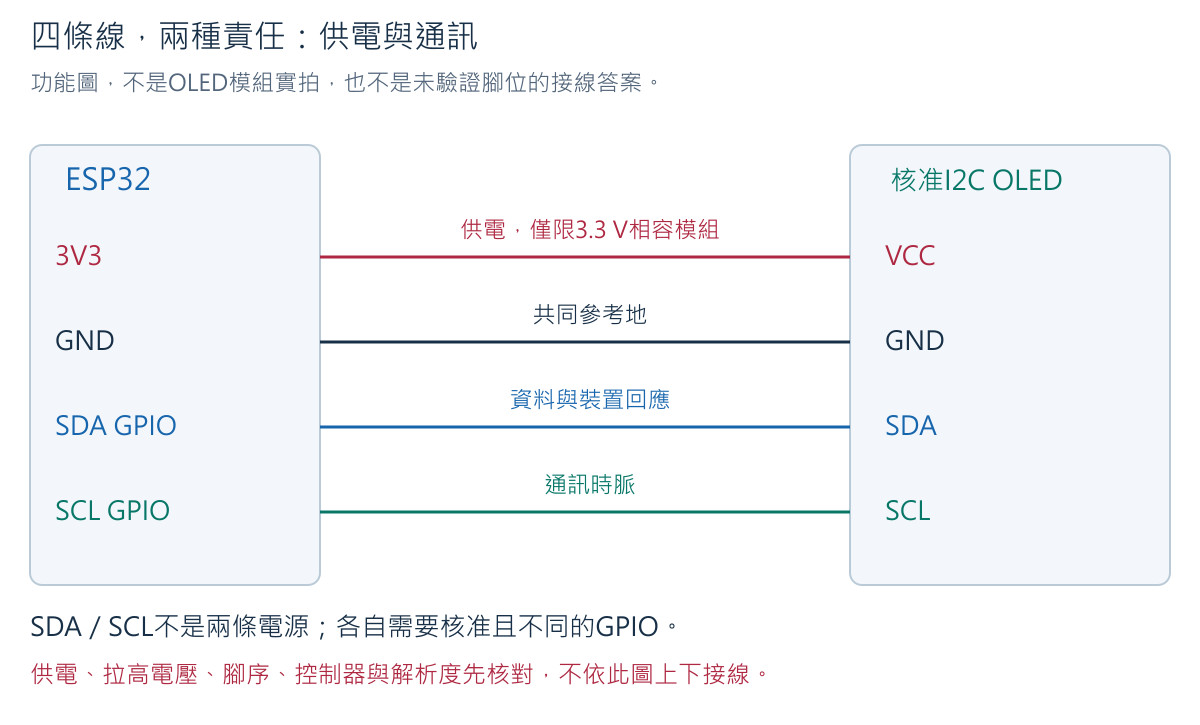

可以把位址比成教室座號：點到這個座號有人答「有」，只知道這個位址有回應，
不能知道對方是哪一種顯示控制器。回到電路，掃描取得的是確認回應（ACK），
不是型號證書，更不是螢幕每個像素已正常顯示的證據。

### 3.1 通電前核對

- 找到模組實物的VCC、GND、SDA、SCL。腳序看不清楚先補拍，不依圖猜。
- 核准模組須能以本課指定電源工作，SDA/SCL拉高電壓須與ESP32的3.3 V邏輯相容。
  「模組可接5 V電源」不能直接推出「資料腳可接ESP32」。
- 如果不是四腳I2C模組、控制器不明或電氣資料缺少，停在辨識與文件核對，不上電掃描。
- 只接OLED時：ESP32 3V3→a6、GND→a3；OLED核准VCC→b6、GND→b3。
  SDA、SCL分別以母對母連核准GPIO。相同列a～e相通，不同列分開，e6、e3保留量測。
  此接法只適用已確認3.3 V供電與訊號相容的模組，不接5Vin。

### 3.2 先掃描，不先猜0x3C

完整範例是[week05_i2c_check.ino](../examples/week05_i2c_check/week05_i2c_check.ino)。
以下程式每次開機只掃一次。`0x`表示十六進位記法；位址不是GPIO編號。
未填核准GPIO或旗標仍為false，會印出blocked，並且不啟動匯流排。


In [ ]:
#include <Wire.h>

// Confirm the exact module's power, logic voltage, pin labels and bus pins first.
const bool ELECTRICAL_PROFILE_CONFIRMED = false;
const int PIN_SDA = -1;
const int PIN_SCL = -1;
bool scanned = false;

void setup() {
  Serial.begin(115200);
  delay(1000); // Startup visibility only; this is not a countdown.
  if (!ELECTRICAL_PROFILE_CONFIRMED || PIN_SDA < 0 || PIN_SCL < 0 ||
      PIN_SDA == PIN_SCL) {
    Serial.println("week=5 status=blocked reason=i2c_electrical_profile_missing");
    return;
  }
  if (!Wire.begin(PIN_SDA, PIN_SCL, 100000)) {
    Serial.println("week=5 status=blocked reason=i2c_begin_failed");
    return;
  }
  Wire.setTimeOut(20);
  int found = 0;
  for (int address = 8; address <= 119; ++address) {
    Wire.beginTransmission(address);
    const uint8_t error = Wire.endTransmission();
    if (error == 0) {
      ++found;
      Serial.printf("event_type=i2c_ack address_7bit=0x%02X model=unknown\n", address);
    }
  }
  scanned = true;
  Serial.printf("event_type=scan_finished found=%d model_verified=false\n", found);
}

void loop() {
  // One scan per boot; never turn ACK into proof of controller or correct wiring.
}


### 3.3 執行與結果判讀

1. 先保留USB拔除、OLED斷開。Arduino IDE使用File → Open開啟上述sketch。
2. 核准電氣與腳位後填SDA/SCL，`ELECTRICAL_PROFILE_CONFIRMED`才可改true。
3. 選本片板的Board與Port；教師BOARD-T01先前用ESP32S3 Dev Module、COM8、
   Flash Size 16 MB、OPI PSRAM。其他電腦的Port與其他板型不能照抄。
4. 按Verify確認編譯。只接裸板USB並Upload；看到`Hash of data verified`是燒錄驗證，
   不是OLED已工作。拔USB後才接OLED，核對完成再上電。
5. 開Tools → Serial Monitor，115200 baud。需要重看掃描時，接線不變再按RST。

以下為示例輸出，非本片OLED實測：

```text
event_type=i2c_ack address_7bit=0x3C model=unknown
event_type=scan_finished found=1 model_verified=false
```

`found=1`是發現一個有回應的位址，不一定等於一塊實物或正確控制器。
`found=0`時先拔USB，核對供電、共同GND、SDA/SCL及核准profile；不能任意增加電壓。
很多位址都回應也不應視為好事，先檢查匯流排與接線。
只接OLED卻出現不符合文件的位址，保存完整log並停止，不選一個「看起來常見」的數字。

**練習**：掃到0x3C，能把SSD1306與SH1106的程式互換嗎？

**預期答案**：不能。相同位址不代表相同指令集、像素配置或初始化方式。
先由模組文件確認控制器與解析度，再選library的對應建構子（constructor）。
它相當於告訴library「要依哪一種顯示器方式建立物件」，不是讓library自動認硬體。


## 4. 先顯示固定文字，再接倒數

本書的完整範例提供SSD1306、128×64、I2C的**有條件版本**。
只有實物核准資料完全符合，才能使用這個建構子並把OLED旗標改true；
若是其他型號，先依官方設定頁改成對應建構子並重新編譯、實機確認，不以換位址替代。

在Sketch → Include Library → Manage Libraries搜尋`U8g2`，確認作者Oliver Kraus，
本次編譯基準為2.36.15。`Wire`隨ESP32 core提供，不需安裝名稱相似的其他套件。
檢查Library Manager顯示的版本並記錄；不把安裝成功當成顯示成功。

本週完整程式有三階段，逐階段只連相應零件：

| LESSON_STAGE | 實物 | 可做的事 | 仍被阻擋的事 |
|---:|---|---|---|
| 0 | 只接USB | 確認預設profile阻擋 | 所有GPIO、I2C初始化 |
| 1 | 核准RGB | `r`紅、`g`綠、`b`藍、`o`全關 | OLED、倒數開始 |
| 2 | 核准OLED | 固定IDLE畫面；輸入3、4顯示示例次數 | RGB、倒數開始 |
| 3 | 核准RGB與OLED | `s`開始、換燈、倒數、`x`中止 | 本週沒有真實遮光計分 |

階段2的初始文字：IDLE／TIME 30 s／NOT RUNNING／DEMO 3/6 NOT SCORE。
這裡的3是預設的示例資料，不是學生已完成三次。依序輸入`4`、`3`，
數字應4再3；不只會往上加，下一週才把同一數字映射到指針。

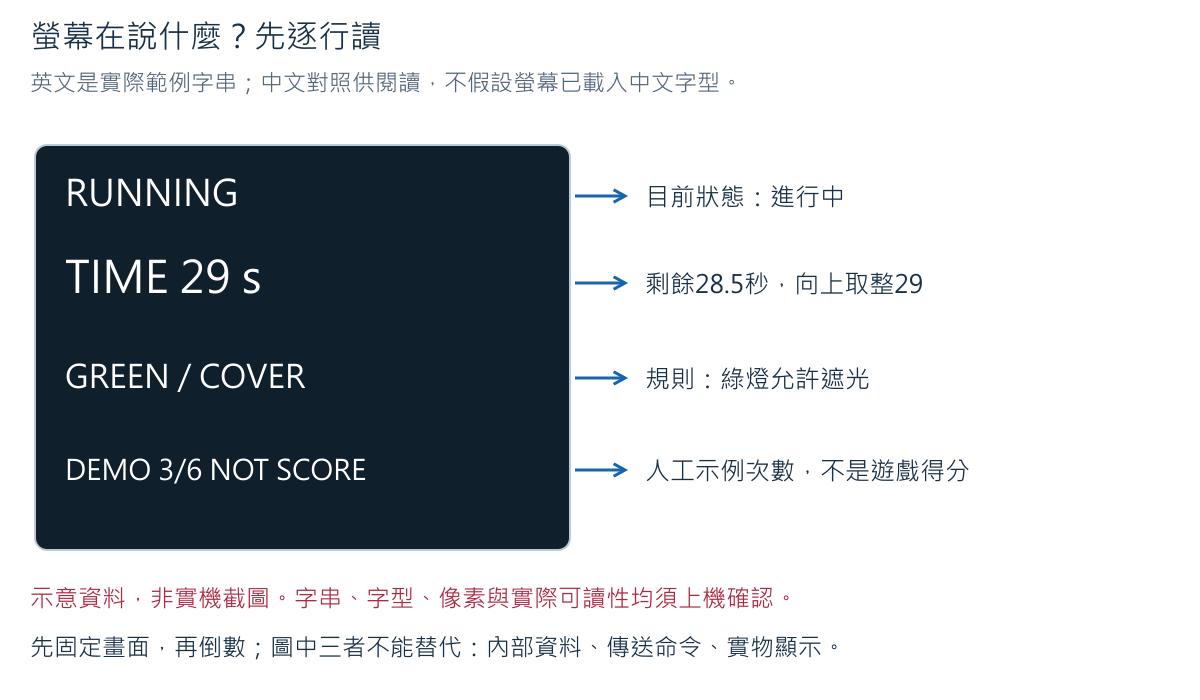

螢幕先用ASCII英文字與數字，旁邊有中文對照，不直接印中文卻期待字型自動存在。
中文字需要有相應字形的字型、正確編碼及實機版面驗證，留作選做，不影響共同成果。

| 英文顯示 | 中文意思 | 判讀限制 |
|---|---|---|
| IDLE | 待機 | 30 s是準備的總時長，尚未計時 |
| RUNNING | 進行中 | 看remaining_ms取得未取整時間 |
| GREEN / COVER | 綠燈／允許遮光 | 本週只提示規則，還不收分 |
| RED / WAIT | 紅燈／等待 | 實物顏色不同要停止排查 |
| DEMO 3/6 NOT SCORE | 示範3/6，不是得分 | 由序列命令輸入，不是sensor算出 |
| EXPIRED | 時間已到 | 不代表遊戲失敗音已測，本週不接蜂鳴器 |
| ABORTED | 已中止 | 查Serial的reason，不能只說「完成」 |


## 5. 30秒不是「印30次」

`millis()`取得開機後的毫秒數。1秒（s）=1000毫秒（ms），
例如開始時10000 ms、現在11500 ms，經過11500−10000=1500 ms，即1.5秒。
設定總長30000 ms，剩下30000−1500=28500 ms，即28.5秒。
這三個值分別是**開始時刻、目前時刻、時間長度**，不要混成同一種「秒數」。

```text
elapsed_ms = now_ms − started_at_ms
remaining_ms = max(0, 30000 − elapsed_ms)
顯示整秒 = (remaining_ms + 999) 整數除以 1000
```

最後一行是向上取整（ceiling）：剩1～1000 ms顯示1，剩1001～2000 ms顯示2。
若剩1499 ms，(1499+999)÷1000的整數結果是2；不是說還有完整兩秒。
剩0時顯示0，程式的截止判定使用`elapsed >= 30000`，不是比對畫面上的文字。

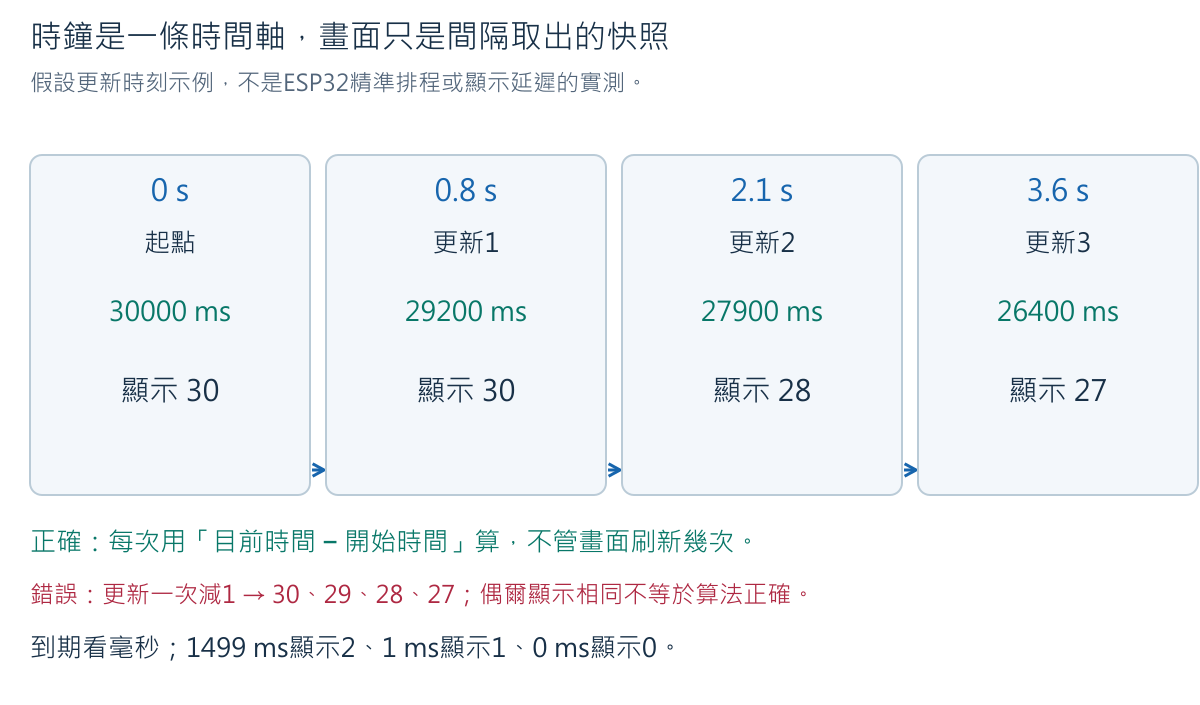

非阻塞式計時不是「所有指令都不花時間」。它表示不讓整個主迴圈為了等一秒而停住。
每輪先問是否到期、處理輸入、適時刷新螢幕，再繼續下一輪。
OLED的I2C傳輸仍是同步工作，會花時間；程式設定匯流排逾時，傳輸後重新讀時間。
20 ms逾時是單次匯流排工作的設定，不是整張畫面或整個中止流程的最長保證。
必須以實機量測輸入處理間隔與畫面延遲，不能直接宣稱「即時」或「零延遲」。

**練習**：若一輪很慢，開始後直到31200 ms才再次檢查30秒期限，要怎麼處理？

**預期答案**：判定到期、剩餘0，不倒退成負數，也不因漏畫兩次而補給玩家兩秒。
但判定已晚1200 ms，應保留這項反應延遲並修正慢操作，不能說硬體精準在30秒停止。

## 6. 完整程式與各區塊的理由

可執行來源：[week05_rgb_oled_timer.ino](../examples/week05_rgb_oled_timer/week05_rgb_oled_timer.ino)。
以下是同一份程式；GPIO與核准旗標預設阻擋。接線前先設定本階段，不把舊程式仍輸出的GPIO拿去接新模組。


In [ ]:
#include <Wire.h>
#include <U8g2lib.h>

// 1: RGB only; 2: OLED only; 3: combined countdown. All start disabled.
const int LESSON_STAGE = 0;
const char* DEVICE_ID = "BOARD-T01";
const bool RGB_PROFILE_CONFIRMED = false;
const bool OLED_PROFILE_CONFIRMED = false;
const int PIN_RGB_R = -1;
const int PIN_RGB_G = -1;
const int PIN_RGB_B = -1;
const int RGB_ON_LEVEL = -1;
const int PIN_SDA = -1;
const int PIN_SCL = -1;
const int OLED_ADDRESS_7BIT = -1;
const bool LIGHT_INTERFERENCE_TEST = false;
const bool LIGHT_PROFILE_CONFIRMED = false;
const int PIN_LIGHT = -1;
// This constructor is ONLY for an approved SSD1306 128x64 I2C module.
// Other controllers/resolutions need a matching reviewed constructor, not a guess.
U8G2_SSD1306_128X64_NONAME_F_HW_I2C oled(U8G2_R0, U8X8_PIN_NONE, PIN_SCL, PIN_SDA);
const uint32_t DURATION_MS = 30000;
const uint32_t PHASE_MS = 3000;
const uint32_t DISPLAY_INTERVAL_MS = 200;
const uint32_t LOG_INTERVAL_MS = 500;
enum TimerState { IDLE, RUNNING, EXPIRED, ABORTED };
TimerState state = IDLE;
bool ready = false, ioFault = false, injectedDisplayFault = false;
bool changed = true, greenPhase = false;
int demoCount = 3;
const char* rgbRequested = "OFF";
uint32_t startedAt = 0, frozenRemaining = DURATION_MS, lastDraw = 0, lastLog = 0;
const char* reason = "boot";

bool hasRgb() { return LESSON_STAGE == 1 || LESSON_STAGE == 3; }
bool hasOled() { return LESSON_STAGE == 2 || LESSON_STAGE == 3; }
bool profileReady() {
  if (LESSON_STAGE < 1 || LESSON_STAGE > 3) return false;
  int pins[6], count = 0;
  if (hasRgb()) {
    if (!RGB_PROFILE_CONFIRMED || (RGB_ON_LEVEL != LOW && RGB_ON_LEVEL != HIGH)) return false;
    pins[count++] = PIN_RGB_R; pins[count++] = PIN_RGB_G; pins[count++] = PIN_RGB_B;
  }
  if (hasOled()) {
    if (!OLED_PROFILE_CONFIRMED || OLED_ADDRESS_7BIT < 8 || OLED_ADDRESS_7BIT > 119) return false;
    pins[count++] = PIN_SDA; pins[count++] = PIN_SCL;
  }
  if (LIGHT_INTERFERENCE_TEST) {
    if (!LIGHT_PROFILE_CONFIRMED) return false;
    pins[count++] = PIN_LIGHT;
  }
  for (int i = 0; i < count; ++i) {
    if (pins[i] < 0) return false;
    for (int j = 0; j < i; ++j) if (pins[i] == pins[j]) return false;
  }
  return true;
}
const char* stateName() {
  switch (state) {
    case IDLE: return "IDLE";
    case RUNNING: return "RUNNING";
    case EXPIRED: return "EXPIRED";
    default: return "ABORTED";
  }
}
uint32_t remainingAt(uint32_t now) {
  if (state != RUNNING) return frozenRemaining;
  const uint32_t elapsed = now - startedAt; // Unsigned subtraction handles one wrap.
  return elapsed >= DURATION_MS ? 0 : DURATION_MS - elapsed;
}
uint32_t displaySeconds(uint32_t remaining) { return (remaining + 999u) / 1000u; }
void rgb(bool r, bool g, bool b) {
  if (!hasRgb() || !ready) return;
  rgbRequested = r ? "RED" : g ? "GREEN" : b ? "BLUE" : "OFF";
  const int off = RGB_ON_LEVEL == HIGH ? LOW : HIGH;
  digitalWrite(PIN_RGB_R, r ? RGB_ON_LEVEL : off);
  digitalWrite(PIN_RGB_G, g ? RGB_ON_LEVEL : off);
  digitalWrite(PIN_RGB_B, b ? RGB_ON_LEVEL : off);
}
void abortTimer(uint32_t now, const char* why) {
  frozenRemaining = remainingAt(now);
  state = ABORTED; greenPhase = false; reason = why; changed = true;
  rgb(false, false, false);
}
void advanceTimer(uint32_t now) {
  if (state != RUNNING) return;
  if (now - startedAt >= DURATION_MS) {
    frozenRemaining = 0; state = EXPIRED; greenPhase = false;
    reason = "deadline"; changed = true; rgb(false, false, false);
  } else {
    const bool next = ((now - startedAt) / PHASE_MS) % 2 == 0;
    if (greenPhase != next) changed = true;
    greenPhase = next; rgb(!greenPhase, greenPhase, false);
  }
}
bool oledAck() {
  if (injectedDisplayFault) return false;
  Wire.beginTransmission(OLED_ADDRESS_7BIT);
  return Wire.endTransmission() == 0;
}
void handleCommand(char c, uint32_t now) {
  if (c == '\r' || c == '\n' || c == ' ') return;
  if (c == 'x') { abortTimer(now, "manual_abort"); return; }
  if (c == 'f' && hasOled()) {
    injectedDisplayFault = true; ioFault = true;
    abortTimer(now, "injected_display_failure"); return;
  }
  if (c == 'c' && hasOled()) {
    injectedDisplayFault = false;
    // Allow a new physical ACK test, but do NOT resume the countdown.
    ioFault = !oledAck();
    reason = ioFault ? "display_still_unresponsive" : "ack_recovered_reset_required";
    changed = true; return;
  }
  if (c == 'z' && state != RUNNING && !ioFault) {
    state = IDLE; frozenRemaining = DURATION_MS; greenPhase = false;
    reason = "manual_reset"; changed = true; rgb(false, false, false); return;
  }
  if (state == IDLE && c >= '0' && c <= '6' && !ioFault) {
    demoCount = c - '0'; reason = "demo_count_changed"; changed = true; return;
  }
  if (c == 's' && LESSON_STAGE == 3 && state == IDLE && !ioFault) {
    startedAt = now; state = RUNNING; reason = "serial_start"; changed = true;
    advanceTimer(now); return;
  }
  if (hasRgb() && state == IDLE && !ioFault && (c == 'r' || c == 'g' || c == 'b' || c == 'o')) {
    rgb(c == 'r', c == 'g', c == 'b');
    Serial.printf("event_type=rgb_test requested=%c visual_verified=false\n", c);
    return;
  }
  Serial.printf("event_type=command_rejected command=%c state=%s\n", c, stateName());
}
void drawSnapshot(uint32_t now) {
  if (!hasOled() || ioFault) return;
  if (!oledAck()) { ioFault = true; abortTimer(millis(), "display_ack_failed"); return; }
  char text[24];
  oled.clearBuffer();
  oled.setFont(u8g2_font_6x12_tf);
  oled.drawStr(0, 12, stateName());
  snprintf(text, sizeof(text), "TIME %lu s", (unsigned long)displaySeconds(remainingAt(now)));
  oled.drawStr(0, 28, text);
  if (state == RUNNING) oled.drawStr(0, 44, greenPhase ? "GREEN / COVER" : "RED / WAIT");
  else {
    snprintf(text, sizeof(text), "RGB %s", rgbRequested);
    oled.drawStr(0, 44, hasRgb() && state == IDLE ? text : "NOT RUNNING");
  }
  snprintf(text, sizeof(text), "DEMO %d/6 NOT SCORE", demoCount);
  oled.drawStr(0, 60, text);
  oled.sendBuffer(); // Finite synchronous bus transfer, NOT zero-duration.
  if (!oledAck()) { ioFault = true; abortTimer(millis(), "display_ack_failed"); }
}
void setup() {
  Serial.begin(115200); delay(1000);
  if (!profileReady()) { Serial.println("week=5 status=blocked reason=profile_missing"); return; }
  ready = true;
  if (hasRgb()) {
    // Set the latch before output mode to reduce startup glitches after setup.
    rgb(false, false, false);
    pinMode(PIN_RGB_R, OUTPUT); pinMode(PIN_RGB_G, OUTPUT); pinMode(PIN_RGB_B, OUTPUT);
  }
  if (hasOled()) {
    if (!Wire.begin(PIN_SDA, PIN_SCL, 100000)) {
      ioFault = true; abortTimer(millis(), "i2c_begin_failed");
    } else {
      Wire.setTimeOut(20);
      if (!oledAck()) { ioFault = true; abortTimer(millis(), "display_ack_failed"); }
      else {
        oled.setI2CAddress(OLED_ADDRESS_7BIT * 2);
        oled.setBusClock(100000); oled.begin(); Wire.setTimeOut(20);
        if (!oledAck()) { ioFault = true; abortTimer(millis(), "display_ack_failed"); }
      }
    }
  }
  if (LIGHT_INTERFERENCE_TEST) {
    analogReadResolution(12); analogSetPinAttenuation(PIN_LIGHT, ADC_11db);
  }
  Serial.println("week=5 commands=r,g,b,o,0..6,s,x,f,c,z baud=115200");
}
void loop() {
  if (!ready) return;
  uint32_t now = millis();
  advanceTimer(now); // Deadline is evaluated before ordinary serial commands.
  if (Serial.available()) handleCommand((char)Serial.read(), now);
  if (now - lastDraw >= DISPLAY_INTERVAL_MS) {
    lastDraw = now; drawSnapshot(now);
  }
  now = millis(); advanceTimer(now); // Refresh after potentially slow I2C work.
  if (changed || now - lastLog >= LOG_INTERVAL_MS) {
    lastLog = now; changed = false;
    Serial.printf("device_id=%s event_type=timer_status state=%s remaining_ms=%lu "
                  "seconds=%lu phase=%s io_ok=%s reason=%s uptime_ms=%lu\n",
                  DEVICE_ID, stateName(), (unsigned long)remainingAt(now),
                  (unsigned long)displaySeconds(remainingAt(now)),
                  state == RUNNING ? (greenPhase ? "GREEN" : "RED") : "OFF",
                  ioFault ? "false" : "true", reason, (unsigned long)now);
    Serial.printf("event_type=view_snapshot demo_count=%d rgb_requested=%s visual_verified=false\n",
                  demoCount, rgbRequested);
    if (LIGHT_INTERFERENCE_TEST) {
      const int raw = analogRead(PIN_LIGHT);
      Serial.printf("event_type=interference_sample light_raw=%d rgb_requested=%s uptime_ms=%lu\n",
                    raw, rgbRequested, (unsigned long)millis());
    }
  }
}


### 6.1 從設定讀到迴圈

| 程式區塊 | 它在做什麼 | 為何需要／具體例子 |
|---|---|---|
| `LESSON_STAGE`與profile旗標 | 決定本次允許用哪些實物 | 階段1不啟動未驗證OLED，階段0什麼都不驅動 |
| `profileReady()` | 檢查旗標、腳號缺值及重複 | 同一GPIO不能一邊控制RGB又當SCL；程式檢查不能替代板卡文件 |
| `RGB_ON_LEVEL` | 記錄亮燈有效準位 | 共陰與共陽的亮／滅邏輯可能相反 |
| `remainingAt(now)` | 從同一局起點算剩餘量 | 沒更新螢幕也不會停表；結果狀態用凍結值 |
| `displaySeconds()` | 只把毫秒轉可讀整秒 | remaining=1仍顯示1，但期限判斷不使用這個1 |
| `advanceTimer()` | 到期優先，再決定當下紅綠階段 | 0～2999 ms綠，3000～5999 ms紅，6000 ms再綠 |
| `handleCommand()` | 每次讀一字元，按狀態接受或拒絕 | 進行中再次s不能重設起點，x中止後z才回待機 |
| `drawSnapshot()` | 以目前資料畫一張快照（snapshot） | 先清RAM緩衝區再畫，不讓舊文字殘留；sendBuffer才傳到OLED |
| `lastDraw`與`lastLog` | 各自控制刷新週期 | 畫面200 ms、log500 ms，兩者均不是計時基準 |
| `ioFault`與注入旗標 | 分清顯示故障與真實遊戲結果 | f是軟體故障；c只重新試ACK，不能自動開始 |

`setI2CAddress(address*2)`是U8g2 API的地址格式要求；Wire掃描仍使用7位址，
例如示例0x3C交給U8g2時乘2。這不是發現了第二個OLED位址，不把掃描範例的0x3C當全班固定答案。
`clearBuffer()`清的是待傳送影像的記憶體，並非關掉OLED電源。
128×64單色畫面的像素緩衝需要128×64÷8=1024 bytes，此外還有程式其他記憶體，
不能只以這1024推算整支程式的RAM使用率。

`uint32_t`保存32位元無號整數；相減可處理一次毫秒計數回繞。
本週每局只有30秒且迴圈持續運作，不是在停機數十天後追算歷史局次。
`delay(1000)`只在啟動時方便看log，倒數迴圈沒有用delay等待一秒。

### 6.2 不把RAM與Flash百分比誤讀

Verify的`Sketch uses`是編譯後程式需要的Flash空間，相對於目前選定的**應用程式分割區上限**，
不是這塊16 MB Flash全體的百分比。`Global variables use`是靜態全域資料的RAM配置，
不等於執行期間所有動態配置、堆疊或PSRAM都算完。安裝顯示library後數字改變可以比較，
但這兩個百分比不能證明OLED接線或畫面正確。


## 7. 分階段實作：先單獨，後整合

### 7.1 RGB三色與全關

依第2節斷電接好核准RGB，程式設階段1，只填RGB必要profile。
依第3.3節的Verify、裸板Upload、斷電接線與上電步驟執行，Serial設115200 baud。
依序在訊息欄輸入`o`、`r`、`g`、`b`、`o`並送出。
每次只送一個字元，Newline可保留，程式忽略換行。

預期是全關、紅、綠、藍、全關；log如`requested=g visual_verified=false`。
`false`提醒程式沒有相機確認實物。把目視顏色記在自己的證據欄，不能把原log改成true冒充程式量到。
不亮或兩色相反，先拔USB查共同端、限流、接線與有效準位，不在帶電狀態換線。

### 7.2 OLED固定畫面

拔USB、移除RGB，只保留核准OLED接線。設定階段2及OLED profile與掃描取得且符合文件的位址。
Verify、Upload後再按斷電接線順序上電。先確認IDLE與TIME 30 s，不應自己倒數。
輸入`4`、`3`，DEMO應對應變化。`s`在階段2會被拒絕，這不是接線壞了。
畫面歪斜、缺行、亂碼時先保存照片、拔USB，核對控制器／解析度／建構子，不能只反覆換位址。

### 7.3 RGB與OLED倒數

1. USB拔除，把已分別核准的RGB與OLED合併。共同GND與3V3功能保持一致，GPIO不得重複。
2. 設階段3；重新核對全部profile，Verify並Upload。初始IDLE、RGB全關、30秒未開始。
3. 輸入`s`。第一段綠燈，約3秒後紅燈，約6秒後再綠，直到30秒到期。
4. 對照螢幕規則文字、實物顏色及`phase`。到期EXPIRED、RGB全關、剩餘0。
5. 送`s`不能直接再開始；先`z`回IDLE，再新的`s`才算新一輪。
6. 下一輪中途`x`，應ABORTED、RGB全關、剩餘值凍結。再`z`才回待機，z本身不計時。

示例log（非實測）逐欄對照：

```text
device_id=BOARD-T01 event_type=timer_status state=RUNNING remaining_ms=28500 seconds=29 phase=GREEN io_ok=true reason=serial_start uptime_ms=11500
event_type=view_snapshot demo_count=3 rgb_requested=GREEN visual_verified=false
```

| 欄位 | 此例的意思 |
|---|---|
| device_id | 裝置代碼，其他組改為不含姓名的代碼；不是COM埠 |
| event_type | 這是一筆timer_status計時狀態；第二行是view_snapshot示例畫面資料 |
| state | 目前進行中，不是結束成功 |
| remaining_ms / seconds | 剩28500毫秒，取整顯示29秒；不是兩個獨立時鐘 |
| phase / rgb_requested | 規則為綠，程式也要求綠；還要目視核對 |
| io_ok | 尚未記錄到本程式能檢出的顯示ACK失敗，不是整套設備完全健康證明 |
| reason | 最近狀態原因為序列開始；不是說每一行都重新開始 |
| uptime_ms | 此筆開機後11500毫秒，不是日期，也不是剩餘時間 |
| demo_count | 人工示例次數，和KY遮光次數無關 |

### 7.4 安全故障與恢復

保持線路不變，在進行中送`f`。這是**軟體注入**的顯示失敗：不拔帶電SDA，
不短接匯流排。應ABORTED、關RGB、Serial顯示`injected_display_failure`與io_ok=false。
OLED可能停留在舊畫面，因為本次故意不再傳送；不能用舊畫面判斷當局狀態。

送`z`應被拒絕。送`c`只取消注入並重做真實ACK檢查：成功時顯示
`ack_recovered_reset_required`，仍ABORTED；畫面下一次更新仍需目視確認。
確認原因已排除、資訊一致後`z`回IDLE，再`s`。
若ACK仍失敗，保持中止、拔USB後檢查，不在同一局自動恢復計時。

ACK只能檢出部分通訊問題，不能知道玻璃是否破裂、像素是否壞、畫面是否正確。
軟體注入通過只證明這條錯誤處理分支，不是完整實體故障測試。


## 8. 同一盞RGB會不會影響光敏？

RGB是光源，KY-018會受光影響。如果綠燈剛亮，sensor數字就跨門檻，
程式可能把自己的燈誤認成玩家手勢。兩個模組單獨正常不等於放一起也正常。

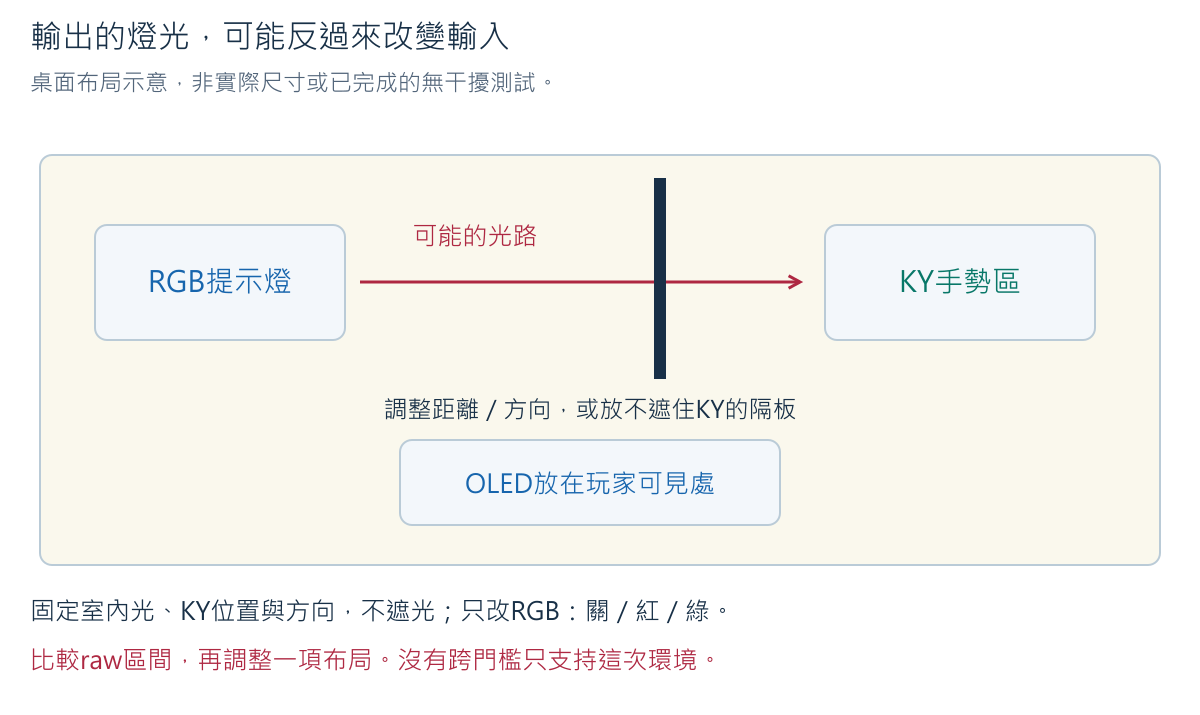

這不是重做Week 3全部校正，而是新增一個有目的的控制變因比較：

1. 拔USB。保留RGB與OLED，把KY中間供電→c6、−→c3、S→a15，
   已核准ADC GPIO經c15接S；e15只作量測延長端，不接任何電源。
2. `LIGHT_INTERFERENCE_TEST=true`、填Week 3本組核准ADC GPIO，
   `LIGHT_PROFILE_CONFIRMED`核准後才true；與SDA/SCL/RGB各腳不同。
   新程式把它當ADC輸入，不沿用曾輸出HIGH的程式。編譯、裸板上傳後斷電接線，再上電。
3. 保持IDLE，固定KY位置、方向、室內光，手不要遮住它。依序`o`全關、`r`紅、`g`綠，
   每種穩定後各保存5筆`interference_sample`。不以換桌或改門檻混淆結果。
4. 比較每組raw最小、最大，及Week 3門檻。若變化會影響分類，先調整距離／方向或以不遮住sensor的遮板隔離RGB光路。
   只調一項，再比較同一條件，不另外增加新光線種類。
5. 未觀察到跨門檻只支持本次布局，不能保證所有教室都沒干擾。留下布局照片與原log。

**預測題**：沒碰KY，綠燈亮時raw由300變250，能說電路短路嗎？

**合理答案**：不能，只知道數字和換燈相關。先排查光學影響，再檢查供電與接線。
若有熱、異味或重啟，立即拔USB；不能為收集數據持續帶故障供電。
數值本身也不能證明變化一定由RGB造成，須固定其他條件重比。

## 9. 深入討論（Discussion）：畫面顯示倒數，時間就一定算對嗎？

以下均為推理示例，不是學生實測。每題先回答，再比對解答；共同主題是「資訊與真正時間的關係」。

### 9.1 更新一次減一秒，哪裡出錯？

**題目**：畫面第一次隔0.8秒更新，第二次隔1.3秒，程式每次都把30減1。兩次之後正確剩多久？

**預期答案**：已過0.8+1.3=2.1秒，應剩27.9秒；向上取整顯示28。
錯誤方法剛好也顯示28，不代表方法正確，因為內部把經過時間當2秒而非2.1。
再遇到延遲，差異會累積。必須保留毫秒與時刻，不只看一次螢幕是否相同。

**常見錯誤**：畫面相同就說兩個算法等價。圖5的更新節點與時間軸說明它們量的不是同一件事。

### 9.2 畫面有1秒，為何仍可能來不及？

**題目**：remaining_ms=1時顯示1。下一次處理時elapsed_ms已達30000，還能用「畫面是1」要求繼續嗎？

**預期答案**：不能。顯示1涵蓋剩1～1000毫秒，還可能是上一張舊快照。
到期以elapsed>=duration判定。這個規則要事先公開；畫面太慢則應改善介面，
不能一面顯示陳舊資訊一面宣稱對玩家完全公平。

### 9.3 改刷新間隔的控制變因練習

**題目**：把DISPLAY_INTERVAL_MS由200改成1500，其他參數不變。
先預測30秒倒數是否變成225秒，再保存兩版本elapsed與remaining的log比較。

**預期答案**：不應變成225秒。1500÷200=7.5倍是畫面週期變慢，
不是時間經過變慢；remaining仍從millis差計算。可以看到畫面跳秒或燈色暫時落後。
每次只改這個常數，不同時改總時長或PHASE_MS。這是刻意延遲畫面，不假稱實物突然變慢。
完成後恢復200，重新確認正常畫面。由log可檢查軟體判定時間，但沒有外部計時參考，
仍不能驗證晶片時鐘的絕對準確度。

### 9.4 畫面綠、實物紅，誰才對？

**題目**：螢幕GREEN，實物亮紅，Serial的phase是RED。可不可以先繼續玩？

**預期答案**：先中止並保存三者證據。可能螢幕快照落後，也可能文字或接線錯。
先比對同一時刻的資料來源，若需改線先拔USB。不能只選對自己有利的顏色，
也不能憑單張照片確定根因。Week 7遊戲使用同一份狀態產生輸出，仍須量實機延遲。

### 9.5 還有ACK，就表示畫面可信？

**題目**：OLED回應ACK，但畫面一半不亮；取消f後c也成功。是否可直接重開比賽？

**預期答案**：不行。ACK只說通訊層有回應，未證明字形與像素正確。
先目視固定畫面、倒數與狀態，保存恢復證據，必要時由教師處理模組。
取消注入只是恢復檢查，不代表每種實體錯誤都已消失。

### 9.6 光線與時間一起變，怎麼解釋？

**題目**：一換紅燈光敏raw就跨門檻，同時畫面掉一秒，能說玩家遮了一次嗎？

**預期答案**：不能。時間變化是時鐘與刷新，raw變化可能是RGB光學干擾，
須回到第8節固定未遮光比較。這兩個現象同時發生不代表有新的手勢事件。
無法控制環境時保留限制，不把有數字、有畫面當成感測真相。


## 10. 依症狀排錯

| 現象 | 第一個安全動作 | 下一項核對 | 不採用的猜測 |
|---|---|---|---|
| profile_missing | 保持模組斷電 | 階段、旗標、重複腳號與核准文件 | 隨意填正整數 |
| 只看到COM8沒有板名 | 不改接線 | 以實際裝置與插拔辨認Port | COM8永遠屬於本板 |
| OLED掃不到 | 拔USB | 四個功能端、供電、拉高電壓、SDA/SCL | 加高電壓試看看 |
| 掃到但顯示亂 | 保存照片再斷電 | 控制器、解析度、建構子與位址格式 | ACK等於型號確認 |
| r亮綠 | 拔USB | R/G路徑、標示與profile | 改log文字掩蓋錯線 |
| s被拒絕 | 保存state | 是否階段3、IDLE且無ioFault | 一直送s重設計時 |
| f後OLED停畫面 | 以Serial查ABORTED | 這是注入情境，c後仍須目視恢復 | 把舊RUNNING當現況 |
| 3V3掉落、重啟、異味 | 立即拔USB | 供電與負載，由教師查核 | 把故障改成程式正常值 |

## 11. 個人證據、完成條件與安全收尾

每組可共用電表，但每位學生要能解釋自己的程式、圖與結果。
紀錄填入實際值，示例不貼成測試成果；沒有硬體時明列「未進行實機驗證」。

| 必要證據 | 要記什麼 | 完成判定 |
|---|---|---|
| profile | 板型、RGB共同端／電流／ON level、GPIO、OLED控制器／解析度／供電／拉高電壓／位址與來源 | 不明欄位不猜；實物階段須全部核准 |
| 單模組 | RGB o/r/g/b/o目視、OLED掃描log與固定畫面 | 要求與觀察一致，ACK與畫面分開 |
| 同步 | 一輪到期、一輪中止，s拒絕、z待機、重新s | 狀態、時間、顏色與畫面可追蹤 |
| 故障 | f、z被拒、c與新ACK、目視恢復、z、s | 注入與硬體來源分開，不自動續局 |
| 比較 | 刷新200/1500 ms預測及log；RGB三條件各5筆raw與布局 | 控制變因、保存原始值、說明限制 |
| Discussion | 六題自己的推理與修正 | 不只抄結論，能指出證據不足處 |

收尾：先送x中止；如要測試o全關，須先確認無故障再送z回IDLE，才送o。任何異常直接拔USB。
保存程式與log後拔USB，電表轉OFF，再拆供電、訊號與共同地並收納。
下一週帶回已核准的RGB/OLED設定與正常證據，再加入舵機；本週沒有舵機或電池已驗證的結論。

## 12. 官方技術依據

- [Espressif I2C API](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/i2c.html)：Wire腳位、傳送與匯流排逾時。
- [U8g2控制器與建構子](https://github.com/olikraus/u8g2/wiki/u8g2setupcpp)：控制器、解析度與硬體I2C版本分開選。
- [U8g2參考](https://github.com/olikraus/u8g2/wiki/u8g2reference)：位址格式、緩衝區、字型與畫面傳送。
- [Arduino Blink Without Delay](https://docs.arduino.cc/built-in-examples/digital/BlinkWithoutDelay/)：以時間差檢查週期。本課倒數、故障與討論為教學延伸。

官方API文件不等於本片模組已驗證；實物資料、編譯、host測試及目視／電氣測試須分開保存。
